# Load and Pre-Process

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np

In [3]:
img_size = 224
batch_size = 32

train_dir = r'D:/Senior_WorkTable/GrowQuest_Data_Final/train'
val_dir = r'D:/Senior_WorkTable/GrowQuest_Data_Final/val'
test_dir = r'D:/Senior_WorkTable/GrowQuest_Data_Final/test' 

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
    )

Found 4199 images belonging to 3 classes.
Found 900 images belonging to 3 classes.
Found 900 images belonging to 3 classes.


In [26]:
np.set_printoptions(linewidth=150)
print(train_generator.classes)
with open("classes_output.txt", "w") as f:
    for label in train_generator.classes:
        f.write(str(label) + "\n")

[0 0 0 ... 2 2 2]


# Build Model 

In [3]:
# --- Base Model ---
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze base model
base_model.trainable = False

# add Early_stopping For original best model

In [4]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_mobilenetv3_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


# FineTune & Training

In [ ]:
# Unfreeze for fine-tuning
base_model.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)
# 70 Epochs
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=70,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/70
132/132 [==============================] - ETA: 0s - loss: 4.0648 - accuracy: 0.3372 - precision: 0.3428 - recall: 0.3013
Epoch 1: val_loss improved from inf to 3.58169, saving model to best_mobilenetv3_model.h5
132/132 [==============================] - 232s 2s/step - loss: 4.0648 - accuracy: 0.3372 - precision: 0.3428 - recall: 0.3013 - val_loss: 3.5817 - val_accuracy: 0.3167 - val_precision: 0.3386 - val_recall: 0.2611 - lr: 1.0000e-05
Epoch 2/70
132/132 [==============================] - ETA: 0s - loss: 3.8373 - accuracy: 0.4172 - precision: 0.4229 - recall: 0.3737
Epoch 2: val_loss improved from 3.58169 to 3.44907, saving model to best_mobilenetv3_model.h5
132/132 [==============================] - 178s 1s/step - loss: 3.8373 - accuracy: 0.4172 - precision: 0.4229 - recall: 0.3737 - val_loss: 3.4491 - val_accuracy: 0.4156 - val_precision: 0.4205 - val_recall: 0.3378 - lr: 1.0000e-05
Epoch 3/70
132/132 [==============================] - ETA: 0s - loss: 3.6152 - accuracy:

# Load best saved model

In [6]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

# Load best saved model from previous training
model = load_model(
    'best_mobilenetv3_model.h5',
    custom_objects={'Precision': Precision, 'Recall': Recall}
)

# Check performance directly after loading
loss, acc, prec, rec = model.evaluate(test_generator)
print(f"Restored model - val_accuracy: {acc:.4f}, val_precision: {prec:.4f}, val_recall: {rec:.4f}")


29/29 [==============================] - 69s 2s/step - loss: 0.5340 - accuracy: 0.9678 - precision: 0.9678 - recall: 0.9678
Restored model - val_accuracy: 0.9678, val_precision: 0.9678, val_recall: 0.9678


In [10]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-6),  # lower LR for more refined training
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

# Continue training
history_continued = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/200
132/132 [==============================] - ETA: 0s - loss: 1.6224 - accuracy: 0.9431 - precision_1: 0.9474 - recall_1: 0.9390
Epoch 1: val_loss improved from inf to 1.64411, saving model to best_mobilenetv3_model.h5
132/132 [==============================] - 215s 2s/step - loss: 1.6224 - accuracy: 0.9431 - precision_1: 0.9474 - recall_1: 0.9390 - val_loss: 1.6441 - val_accuracy: 0.9367 - val_precision_1: 0.9407 - val_recall_1: 0.9344 - lr: 1.0000e-06
Epoch 2/200
132/132 [==============================] - ETA: 0s - loss: 1.6114 - accuracy: 0.9505 - precision_1: 0.9544 - recall_1: 0.9464
Epoch 2: val_loss improved from 1.64411 to 1.64268, saving model to best_mobilenetv3_model.h5
132/132 [==============================] - 184s 1s/step - loss: 1.6114 - accuracy: 0.9505 - precision_1: 0.9544 - recall_1: 0.9464 - val_loss: 1.6427 - val_accuracy: 0.9378 - val_precision_1: 0.9407 - val_recall_1: 0.9344 - lr: 1.0000e-06
Epoch 3/200
132/132 [==============================] - ETA: 0s

# check Graph 

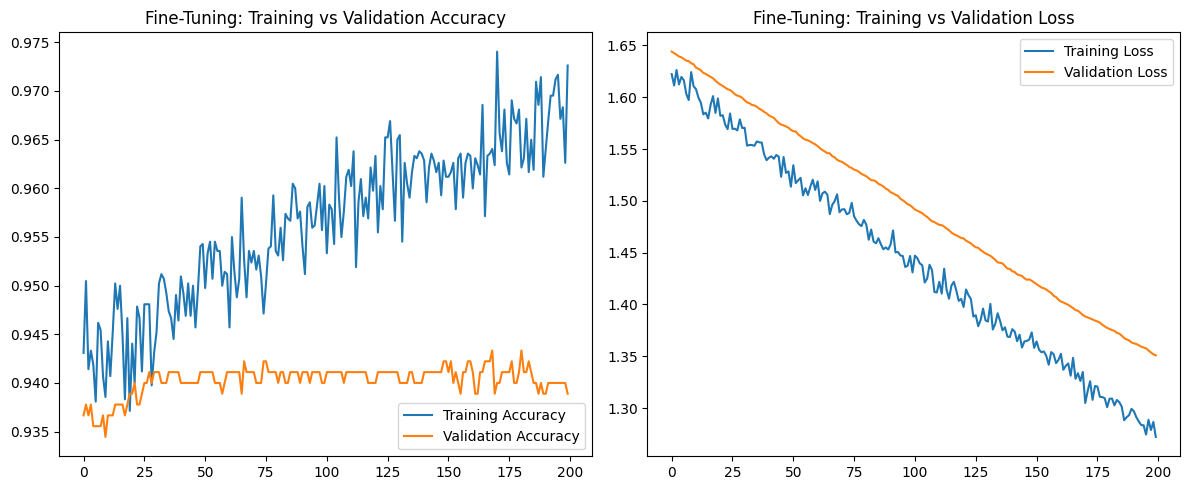

In [11]:
import matplotlib.pyplot as plt

# Extract history
acc = history_continued.history['accuracy']
val_acc = history_continued.history['val_accuracy']
loss = history_continued.history['loss']
val_loss = history_continued.history['val_loss']

epochs_range = range(len(acc))

# Plot
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Fine-Tuning: Training vs Validation Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Fine-Tuning: Training vs Validation Loss')

plt.tight_layout()
plt.show()


In [39]:
from tensorflow.keras.models import load_model

model = load_model('best_mobilenetv3_model.h5')

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 900 images belonging to 3 classes.


29/29 [==============================] - 28s 944ms/step
Accuracy: 95.67%


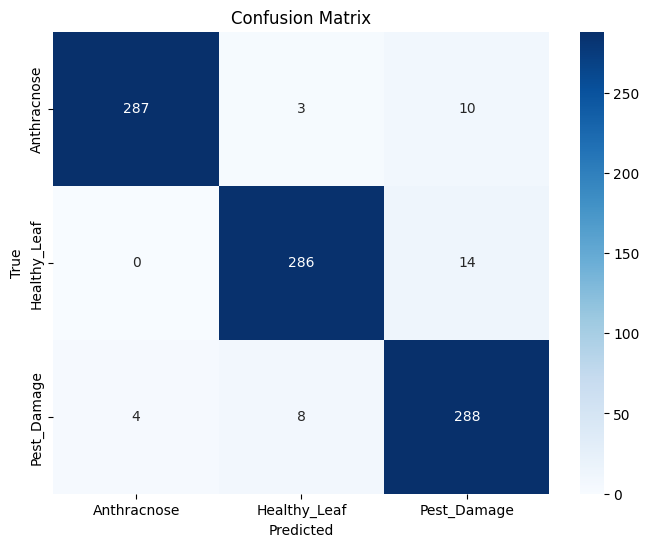

In [40]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes


accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_true, y_pred)

class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

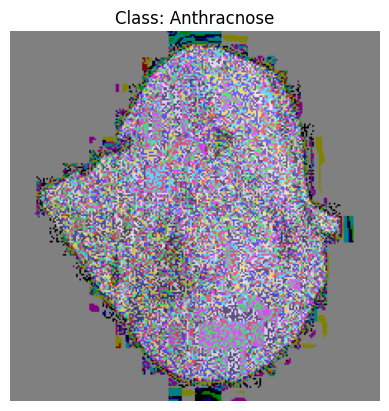

In [47]:
# Get first batch (images and labels)
images, labels = val_generator[1]  # batch index 0

# Get first image and its one-hot label
first_image = images[1]
first_label = labels[1]

# Decode label (if needed)
import numpy as np
class_indices = val_generator.class_indices
class_names = list(class_indices.keys())
decoded_label = class_names[np.argmax(first_label)]

# Plot
import matplotlib.pyplot as plt

plt.imshow((first_image * 127.5 + 127.5).astype("uint8"))  # unnormalize from [-1,1] if using MobileNetV3
plt.title(f"Class: {decoded_label}")
plt.axis('off')
plt.show()


In [60]:
images, _ = val_generator[6]  # Get only the inputs (X), ignore labels (y)
y_pred_prob = model.predict(images, verbose=1)

y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred)

1/1 [==============================] - 0s 32ms/step
[2 2 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [61]:
image = images[6]
image = np.expand_dims(image, axis=0)  # Add batch dimension

pred_prob = model.predict(image)
pred_class = np.argmax(pred_prob)

print(f"Predicted class index: {pred_class}")


1/1 [==============================] - 0s 32ms/step
Predicted class index: 0


# Testing with Diffence Data that not in /train ,/val /test

Found 900 images belonging to 3 classes.
Found 6 images belonging to 1 classes.
6/6 [==============================] - 1s 27ms/step


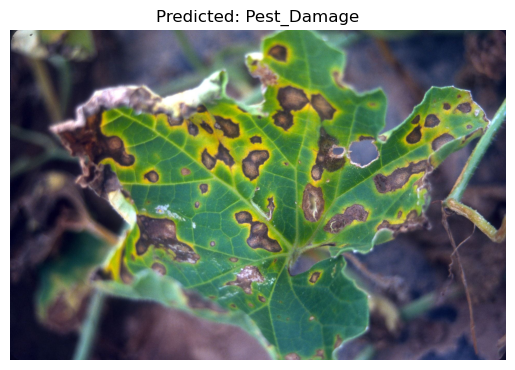

In [ ]:

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)
# 1. Load your best model (same as before)
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

model = load_model(
    'best_mobilenetv3_model.h5',
    custom_objects={'Precision': Precision, 'Recall': Recall}
)

# 2. Use the same preprocessing pipeline as val_generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. Load the image using flow_from_directory
test_dir = r'D:/Senior_WorkTable/Customtest'  # Path to the folder you created

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=1,
    class_mode=None,       # No labels required
    shuffle=True
)

# 4. Make prediction
import numpy as np
import matplotlib.pyplot as plt

predictions = model.predict(test_generator)
predicted_index = np.argmax(predictions[0])  # first image only

# Use the same label map from val_generator
class_names = list(val_generator.class_indices.keys())
predicted_class = class_names[predicted_index]


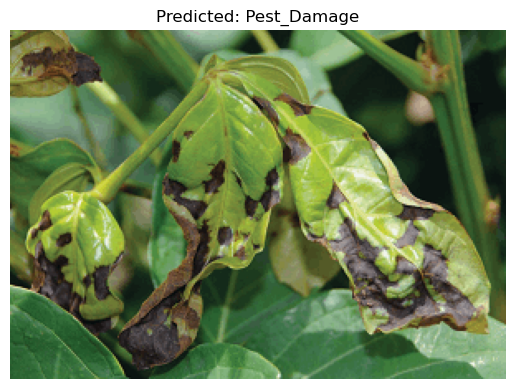

In [13]:

# 5. Show result
img_path = test_generator.filepaths[0]  # first image file path
img = plt.imread(img_path)
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()


# Load best Saved model 2nd & check accuracy

In [4]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

# Load best saved model from previous training
model = load_model(
    'best_mobilenetv3_model.h5',
    custom_objects={'Precision': Precision, 'Recall': Recall}
)

# Evaluate and unpack loss, accuracy, precision, recall
val_loss, acc, prec, rec = model.evaluate(val_generator)

# Print all metrics
print(f"Restored model - val_loss: {val_loss:.4f}, val_accuracy: {acc:.4f}, "
      f"val_precision: {prec:.4f}, val_recall: {rec:.4f}")


29/29 [==============================] - 82s 3s/step - loss: 1.3502 - accuracy: 0.9389 - precision_1: 0.9430 - recall_1: 0.9367
Restored model - val_loss: 1.3502, val_accuracy: 0.9389, val_precision: 0.9430, val_recall: 0.9367


# Training 3rd to lower val_loss value 

In [13]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

model = load_model(
    'best_mobilenetv3_model.h5',
    custom_objects={'Precision': Precision, 'Recall': Recall}
)

In [14]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

history_refine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,  
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/100
132/132 [==============================] - ETA: 0s - loss: 1.2728 - accuracy: 0.9659 - precision: 0.9675 - recall: 0.9655
Epoch 1: val_loss improved from inf to 1.32884, saving model to best_mobilenetv3_model.h5
132/132 [==============================] - 480s 4s/step - loss: 1.2728 - accuracy: 0.9659 - precision: 0.9675 - recall: 0.9655 - val_loss: 1.3288 - val_accuracy: 0.9444 - val_precision: 0.9475 - val_recall: 0.9422 - lr: 1.0000e-05
Epoch 2/100
132/132 [==============================] - ETA: 0s - loss: 1.2490 - accuracy: 0.9688 - precision: 0.9701 - recall: 0.9674
Epoch 2: val_loss improved from 1.32884 to 1.32364, saving model to best_mobilenetv3_model.h5
132/132 [==============================] - 424s 3s/step - loss: 1.2490 - accuracy: 0.9688 - precision: 0.9701 - recall: 0.9674 - val_loss: 1.3236 - val_accuracy: 0.9411 - val_precision: 0.9453 - val_recall: 0.9400 - lr: 1.0000e-05
Epoch 3/100
132/132 [==============================] - ETA: 0s - loss: 1.2314 - accura

KeyboardInterrupt: 

# Recheck the Val_Loss , Val_Acc , Load_Model

In [5]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

model = load_model(
    'best_mobilenetv3_model.h5',
    custom_objects={'Precision': Precision, 'Recall': Recall}
)


In [6]:
loss, acc, prec, rec = model.evaluate(val_generator)
print(f"Best Model: val_loss={loss:.4f}, val_acc={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}")


29/29 [==============================] - 82s 3s/step - loss: 0.5309 - accuracy: 0.9656 - precision: 0.9655 - recall: 0.9644
Best Model: val_loss=0.5309, val_acc=0.9656, precision=0.9655, recall=0.9644


# Test the performance current Model 

In [26]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

# Get class names and labels in the correct order
class_names = list(test_generator.class_indices.keys())
labels = list(test_generator.class_indices.values())

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names
))


29/29 [==============================] - 84s 3s/step
              precision    recall  f1-score   support

 Anthracnose       0.98      0.98      0.98       300
Healthy_Leaf       0.96      0.97      0.97       300
 Pest_Damage       0.96      0.95      0.95       300

    accuracy                           0.97       900
   macro avg       0.97      0.97      0.97       900
weighted avg       0.97      0.97      0.97       900



29/29 [==============================] - 71s 3s/step


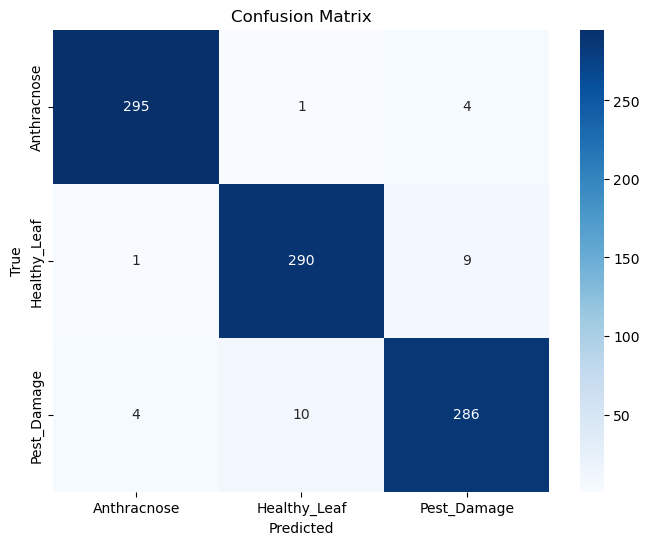

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and true labels
y_pred = np.argmax(model.predict(test_generator), axis=1)
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# Hyperparameter (KerasTuner)

Define the HyperModel 

In [5]:
import keras_tuner as kt
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

def build_model(hp):
    base_model = MobileNetV3Large(include_top=False, input_shape=(224, 224, 3), weights='imagenet')
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(hp.Float('dropout_rate_1', 0.2, 0.5, step=0.1))(x)
    x = Dense(
        hp.Int('dense_units', min_value=64, max_value=256, step=64),
        activation='relu',
        kernel_regularizer=l2(hp.Choice('l2_reg', [1e-2, 1e-3, 1e-4]))
    )(x)
    x = BatchNormalization()(x)
    x = Dropout(hp.Float('dropout_rate_2', 0.2, 0.5, step=0.1))(x)
    output = Dense(train_generator.num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-3, 1e-4, 1e-5])),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Run the Tuner (If already finish dont run this cell !!!)

In [8]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='kerastuner_logs',
    project_name='mobilenetv3_tune'
)

tuner.search(train_generator, validation_data=val_generator, epochs=10)


Trial 10 Complete [01h 10m 34s]
val_loss: 3.6351819038391113

Best val_loss So Far: 0.3908067047595978
Total elapsed time: 11h 44m 34s


# Re load  tuner 

In [6]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='kerastuner_logs',
    project_name='mobilenetv3_tune'
)

Reloading Tuner from kerastuner_logs\mobilenetv3_tune\tuner0.json


# Compare Original Model vs KerasTuner Best Hyperparameters

In [15]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

# Load your previous best manually trained model
original_model = load_model('best_mobilenetv3_model.h5',
                            custom_objects={'Precision': Precision, 'Recall': Recall})

# Evaluate it
loss, acc, prec, rec = original_model.evaluate(test_generator)
print(f"Original model: val_loss={loss:.4f}, acc={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}")


29/29 [==============================] - 68s 2s/step - loss: 0.5340 - accuracy: 0.9678 - precision: 0.9678 - recall: 0.9678
Original model: val_loss=0.5340, acc=0.9678, precision=0.9678, recall=0.9678


In [7]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest hyperparameters from tuning:")
for param in best_hp.values:
    print(f"{param}: {best_hp.get(param)}")


Best hyperparameters from tuning:
dropout_rate_1: 0.30000000000000004
dense_units: 64
l2_reg: 0.0001
dropout_rate_2: 0.30000000000000004
lr: 0.001


# Retrieve the Best Hyperparameters

In [8]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

# (Optional) View them
print("Best hyperparameters:")
for param in best_hp.values:
    print(f"{param}: {best_hp.get(param)}")


Best hyperparameters:
dropout_rate_1: 0.30000000000000004
dense_units: 64
l2_reg: 0.0001
dropout_rate_2: 0.30000000000000004
lr: 0.001


# Build a Model with Best Hyperparameters the Compile and Train the Model Fully

In [9]:
model = build_model(best_hp)

Add early_stop for hyperparameter model

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. Early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,  # ⬅️ increase slightly to let model settle
    restore_best_weights=True,
    verbose=1
)

# 2. Reduce LR on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,  # ⬅️ give slightly more time to adapt
    min_lr=1e-6,
    verbose=1
)

# 3. Model checkpoint (avoid overwriting + more organized)
checkpoint = ModelCheckpoint(
    filepath='hp_checkpoint/mobilenetv3_best_tuned_final.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,  # keep full model for loading
    verbose=1
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=70,  
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/70
132/132 [==============================] - ETA: 0s - loss: 0.9552 - accuracy: 0.6282
Epoch 1: val_loss improved from inf to 0.51015, saving model to hp_checkpoint\mobilenetv3_best_tuned_final.h5
132/132 [==============================] - 489s 4s/step - loss: 0.9552 - accuracy: 0.6282 - val_loss: 0.5101 - val_accuracy: 0.8000 - lr: 0.0010
Epoch 2/70
132/132 [==============================] - ETA: 0s - loss: 0.6645 - accuracy: 0.7330
Epoch 2: val_loss improved from 0.51015 to 0.45477, saving model to hp_checkpoint\mobilenetv3_best_tuned_final.h5
132/132 [==============================] - 420s 3s/step - loss: 0.6645 - accuracy: 0.7330 - val_loss: 0.4548 - val_accuracy: 0.8311 - lr: 0.0010
Epoch 3/70
132/132 [==============================] - ETA: 0s - loss: 0.6035 - accuracy: 0.7504
Epoch 3: val_loss improved from 0.45477 to 0.44049, saving model to hp_checkpoint\mobilenetv3_best_tuned_final.h5
132/132 [==============================] - 443s 3s/step - loss: 0.6035 - accuracy: 0

# Evaluate on Test Set with Best Hyperparameters

In [ ]:
model.save('mobilenetv3_best_tuned_final.h5')
model.evaluate(test_generator)


29/29 [==============================] - 70s 2s/step - loss: 0.2727 - accuracy: 0.9033


[0.2726585865020752, 0.903333306312561]

In [17]:
# Evaluate and print results
val_loss, val_acc = model.evaluate(test_generator, verbose=0)
print(f"\nTuned Model Performance on Test Set:")
print(f"val_loss: {val_loss:.4f}")
print(f"val_accuracy: {val_acc:.4f}")


Tuned Model Performance on Test Set:
val_loss: 0.2727
val_accuracy: 0.9033


# ROC Curves 

In [9]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

# Load model 1 (manually trained)
model_1 = load_model('best_mobilenetv3_model.h5',
                     custom_objects={'Precision': Precision, 'Recall': Recall})

# Load model 2 (tuned)
model_2 = load_model('hp_checkpoint/mobilenetv3_best_tuned_final.h5',
                     custom_objects={'Precision': Precision, 'Recall': Recall})


In [10]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# One-hot encode the true labels
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

# Predict probabilities from both models
y_score_original = model_1.predict(test_generator)  # e.g. best_mobilenetv3_model.h5
y_score_tuned = model_2.predict(test_generator)     # e.g. mobilenetv3_best_tuned_final.h5


29/29 [==============================] - 75s 3s/step


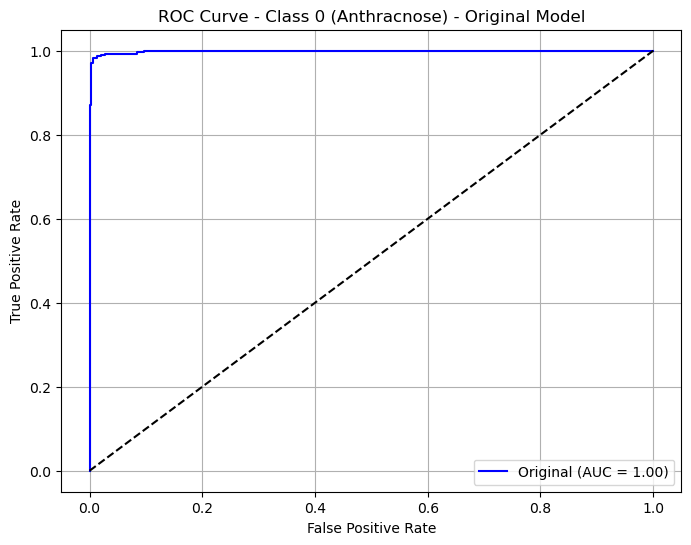

In [11]:
fpr1, tpr1, _ = roc_curve(y_true_bin[:, 0], y_score_original[:, 0])
auc1 = auc(fpr1, tpr1)

plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, label=f"Original (AUC = {auc1:.2f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Class 0 (Anthracnose) - Original Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


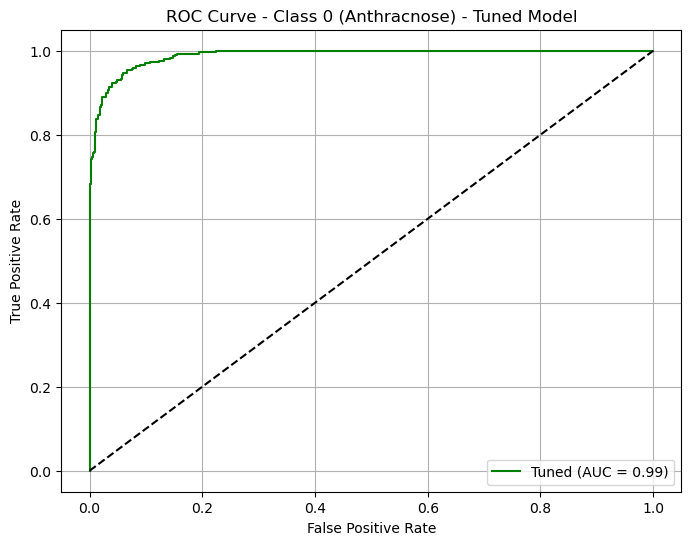

In [12]:
fpr2, tpr2, _ = roc_curve(y_true_bin[:, 0], y_score_tuned[:, 0])
auc2 = auc(fpr2, tpr2)

plt.figure(figsize=(8,6))
plt.plot(fpr2, tpr2, label=f"Tuned (AUC = {auc2:.2f})", color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Class 0 (Anthracnose) - Tuned Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


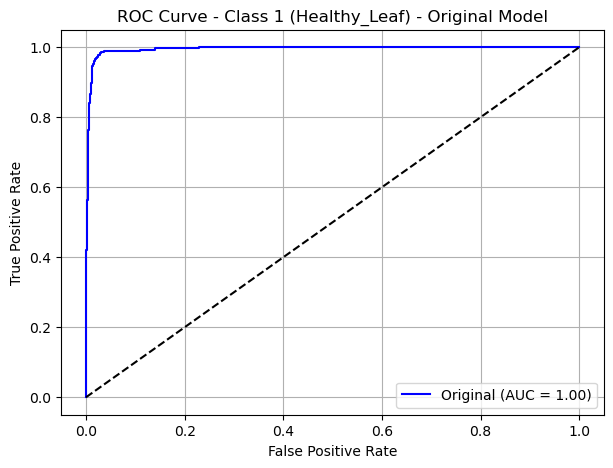

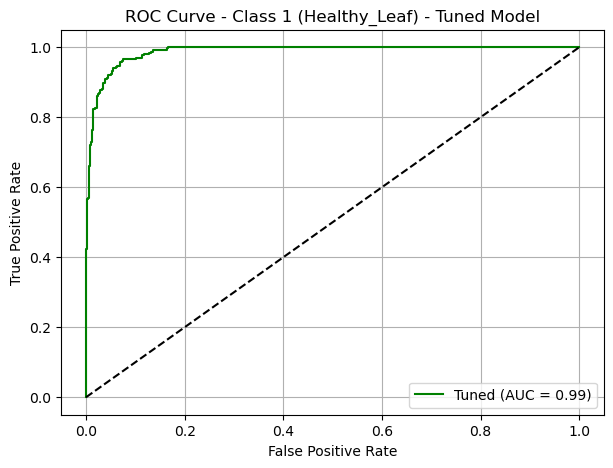

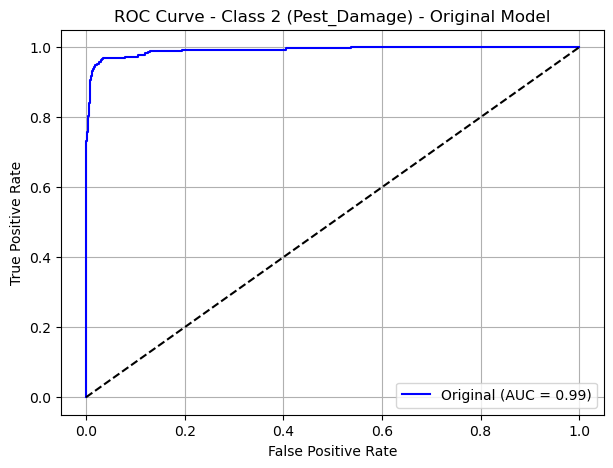

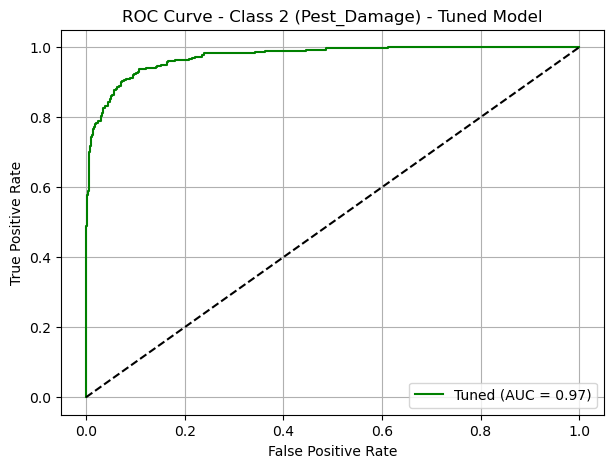

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def compute_roc(y_true_bin, y_score, class_index):
    fpr, tpr, _ = roc_curve(y_true_bin[:, class_index], y_score[:, class_index])
    auc_score = auc(fpr, tpr)
    return fpr, tpr, auc_score

# Loop through classes 1 and 2
for class_idx in [1, 2]:
    class_name = class_names[class_idx]

    # Original model
    fpr_orig, tpr_orig, auc_orig = compute_roc(y_true_bin, y_score_original, class_idx)

    # Tuned model
    fpr_tuned, tpr_tuned, auc_tuned = compute_roc(y_true_bin, y_score_tuned, class_idx)

    # Plot original
    plt.figure(figsize=(7, 5))
    plt.plot(fpr_orig, tpr_orig, label=f'Original (AUC = {auc_orig:.2f})', color='blue')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - Class {class_idx} ({class_name}) - Original Model')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    # Plot tuned
    plt.figure(figsize=(7, 5))
    plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned (AUC = {auc_tuned:.2f})', color='green')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - Class {class_idx} ({class_name}) - Tuned Model')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


In [15]:
from collections import Counter

# For training data
train_counts = Counter(train_generator.classes)
print("Training data class distribution:")
for class_name, index in train_generator.class_indices.items():
    print(f"{class_name}: {train_counts[index]}")

# For validation data
val_counts = Counter(val_generator.classes)
print("\nValidation data class distribution:")
for class_name, index in val_generator.class_indices.items():
    print(f"{class_name}: {val_counts[index]}")

# For test data
test_counts = Counter(test_generator.classes)
print("\nTest data class distribution:")
for class_name, index in test_generator.class_indices.items():
    print(f"{class_name}: {test_counts[index]}")

Training data class distribution:
Anthracnose: 1400
Healthy_Leaf: 1399
Pest_Damage: 1400

Validation data class distribution:
Anthracnose: 300
Healthy_Leaf: 300
Pest_Damage: 300

Test data class distribution:
DummyClass: 6


# Test on new data that not seen before (Original best Model)

In [5]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall

# Load your previous best manually trained model
original_model = load_model('best_mobilenetv3_model.h5',
                            custom_objects={'Precision': Precision, 'Recall': Recall})

# Evaluate it
loss, acc, prec, rec = original_model.evaluate(test_generator)
print(f"Original model: val_loss={loss:.4f}, acc={acc:.4f}, precision={prec:.4f}, recall={rec:.4f}")


29/29 [==============================] - 83s 3s/step - loss: 0.5340 - accuracy: 0.9678 - precision: 0.9678 - recall: 0.9678
Original model: val_loss=0.5340, acc=0.9678, precision=0.9678, recall=0.9678


In [17]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
import numpy as np
import os

# 1. Load your best trained model
model = load_model(
    'mobilenetv3_best_tuned_final.h5',
    custom_objects={'Precision': Precision, 'Recall': Recall}
)

# 2. Preprocessing pipeline (same as during training)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 3. Path to new unseen test images
test_dir = r'E:\TEST'

# 4. Load all images (batch_size=1 = one-by-one)
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

# 5. Predict all
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)

# 6. Define original class list
class_names = ['Anthracnose', 'Healthy_Leaf', 'Pest_Damage']
idx_to_class = {i: name for i, name in enumerate(class_names)}

# 7. Print class list first
print("Your original model was trained on", len(class_names), "classes:")
for idx, name in idx_to_class.items():
    print(f"• {idx}: {name}")
print()

# 8. Print predictions for each image
for i in range(len(test_generator.filenames)):
    filename = test_generator.filenames[i]
    pred_idx = y_pred[i]
    pred_class = idx_to_class.get(pred_idx, "Unknown")
    print(f"📷 {filename} → Predicted: {pred_idx}: {pred_class}")


Found 39 images belonging to 2 classes.
2/2 [==============================] - 1s 239ms/step
Your original model was trained on 3 classes:
• 0: Anthracnose
• 1: Healthy_Leaf
• 2: Pest_Damage

📷 Anthracnose_Test\Anthracnose_Sample_1.jpg → Predicted: 0: Anthracnose
📷 Anthracnose_Test\Anthracnose_Sample_10.jpeg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_11.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_12.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_13.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_14.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_15.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_16.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_17.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_18.jpg → Predicted: 2: Pest_Damage
📷 Anthracnose_Test\Anthracnose_Sample_19.jpg → Predicted: 2: Pest_Damage
📷 Ant

# Convert the Model to TensorFlow Lite (TFLite)

In [1]:
import tensorflow as tf

model = tf.keras.models.load_model('mobilenetv3_best_tuned_final.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Optional: quantization
tflite_model = converter.convert()

with open('mobilenetv3_best_tuned_final.tflite', 'wb') as f:
    f.write(tflite_model)


c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


INFO:tensorflow:Assets written to: C:\Users\pondt\AppData\Local\Temp\tmpgxkrd175\assets


INFO:tensorflow:Assets written to: C:\Users\pondt\AppData\Local\Temp\tmpgxkrd175\assets


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, log_loss

# Settings
img_size = 224
batch_size = 1
test_dir = "D:/Senior_WorkTable/GrowQuest_Data_Final/test"  # folder with subdirs for each class
class_names = ['Anthracnose', 'Healthy_Leaf', 'Pest_Damage']

# Build generator
datagen = ImageDataGenerator(rescale=1./255)
test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',  # to get true labels
    shuffle=False
)

# Map labels
class_indices = test_gen.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="mobilenetv3_best_tuned_final.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Inference loop
y_true = []
y_pred_probs = []
filenames = test_gen.filenames

print(f"🔍 Evaluating {len(filenames)} images...")

for i in range(len(filenames)):
    img = test_gen[i][0]  # get batch of 1 image
    label = test_gen[i][1]  # one-hot label

    # Run inference
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    y_pred_probs.append(output)
    y_true.append(np.argmax(label))

    pred_idx = np.argmax(output)
    confidence = np.max(output)
    print(f"{filenames[i]} → {class_names[pred_idx]} ({confidence:.2f})")

# Accuracy and val_loss
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_true, y_pred)
loss = log_loss(y_true, y_pred_probs)

print(f"\n✅ Evaluation complete:")
print(f"val_accuracy: {acc:.4f}")
print(f"val_loss: {loss:.4f}")


Found 900 images belonging to 3 classes.


ValueError: Model provided has model identifier '

', should be 'TFL3'


In [10]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, log_loss
import numpy as np

# Path to your .h5 model
model = load_model("C:/Users/pondt/MainSenior/GrowQuest-Tower/Processing/BackUp2/best_mobilenetv3_model.h5")  # or "mobilenetv3_best_tuned_final.h5"

# Optional: if custom metrics were used during training
# model = load_model("your_model.h5", custom_objects={'Precision': Precision, 'Recall': Recall})


In [ ]:
img_size = 224
batch_size = 32
test_dir = "D:/Senior_WorkTable/GrowQuest_Data_Final/test"  # your folder structure

datagen = ImageDataGenerator(rescale=1./255)
test_gen = datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 900 images belonging to 3 classes.


In [12]:
# Evaluate directly (gives loss and accuracy)
results = model.evaluate(test_gen, verbose=1)

print("\n✅ Evaluation Results:")
print(f"val_loss: {results[0]:.4f}")
print(f"val_accuracy: {results[1]:.4f}")
print(f"val_precision: {results[2]:.4f}")
print(f"val_recall: {results[3]:.4f}")


900/900 [==============================] - 71s 78ms/step - loss: 5.0910 - accuracy: 0.3333 - precision: 0.3333 - recall: 0.3333

✅ Evaluation Results:
val_loss: 5.0910
val_accuracy: 0.3333
val_precision: 0.3333
val_recall: 0.3333


In [ ]:
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Show predictions
for i in range(len(test_gen.filenames)):
    filename = test_gen.filenames[i]
    pred_class = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])
    print(f"{filename} → Predicted: {pred_class} ({confidence:.2f})")
